In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("food_delivery_dataset.xlsx")

In [4]:
df.head()

,Order_ID,Customer_ID,City,Restaurant_Type,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Payment_Method,Repeat_Customer
0,1,2047,Mumbai,Cafe,248.17,5.3,58,1.8,Cash,0
1,2,2068,Delhi,Cloud Kitchen,1737.40,8.8,60,4.7,Cash,0
2,3,2025,Mumbai,Cafe,2875.24,32.0,75,2.8,Cash,0
3,4,2067,Hyderabad,Cafe,2030.41,20.3,57,3.9,UPI,1
4,5,2083,Delhi,Fast Food,2693.69,20.6,19,1.2,UPI,0


In [5]:
df["Final_Price"]=df["Order_Value"]*(1-df["Discount_Percent"]/100)

In [6]:
df.head()

,Order_ID,Customer_ID,City,Restaurant_Type,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Payment_Method,Repeat_Customer,Final_Price
0,1,2047,Mumbai,Cafe,248.17,5.3,58,1.8,Cash,0,235.01699
1,2,2068,Delhi,Cloud Kitchen,1737.40,8.8,60,4.7,Cash,0,1584.50880
2,3,2025,Mumbai,Cafe,2875.24,32.0,75,2.8,Cash,0,1955.16320
3,4,2067,Hyderabad,Cafe,2030.41,20.3,57,3.9,UPI,1,1618.23677
4,5,2083,Delhi,Fast Food,2693.69,20.6,19,1.2,UPI,0,2138.78986


In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               250 non-null    int64  
 1   Customer_ID            250 non-null    int64  
 2   City                   250 non-null    object 
 3   Restaurant_Type        250 non-null    object 
 4   Order_Value            250 non-null    float64
 5   Discount_Percent       250 non-null    float64
 6   Delivery_Time_Minutes  250 non-null    int64  
 7   Customer_Rating        250 non-null    float64
 8   Payment_Method         250 non-null    object 
 9   Repeat_Customer        250 non-null    int64  
 10  Final_Price            250 non-null    float64
dtypes: float64(4), int64(4), object(3)
memory usage: 21.6+ KB


In [8]:
df.describe()

,Order_ID,Customer_ID,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Repeat_Customer,Final_Price
count,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000
mean,125.500000,2049.308000,1594.487080,20.31960,52.520000,2.980000,0.38000,1271.205037
std,72.312977,28.690796,842.735563,10.71226,21.861043,1.168702,0.48636,698.510898
min,1.000000,2000.000000,150.020000,0.00000,15.000000,1.000000,0.00000,107.204580
25%,63.250000,2024.250000,885.830000,11.45000,34.250000,2.000000,0.00000,640.156290
50%,125.500000,2048.000000,1568.980000,20.55000,53.000000,2.900000,0.00000,1218.038730
75%,187.750000,2074.500000,2347.015000,29.17500,71.000000,4.000000,1.00000,1827.288480
max,250.000000,2099.000000,2994.840000,39.50000,89.000000,4.900000,1.00000,2649.330210


In [9]:
df.isna().sum()

Order_ID                 0
Customer_ID              0
City                     0
Restaurant_Type          0
Order_Value              0
Discount_Percent         0
Delivery_Time_Minutes    0
Customer_Rating          0
Payment_Method           0
Repeat_Customer          0
Final_Price              0
dtype: int64

In [10]:
df["City"].value_counts()

City
Bangalore    67
Delhi        64
Mumbai       62
Hyderabad    57
Name: count, dtype: int64

In [11]:
df["Restaurant_Type"].value_counts()

Restaurant_Type
Fast Food        72
Cafe             69
Casual Dining    55
Cloud Kitchen    54
Name: count, dtype: int64

In [12]:
df["Payment_Method"].value_counts()

Payment_Method
UPI     87
Card    85
Cash    78
Name: count, dtype: int64

In [13]:
df["Repeat_Customer"].value_counts()

Repeat_Customer
0    155
1     95
Name: count, dtype: int64

In [14]:
df["Repeat_Label"] = df["Repeat_Customer"].map({1: "Yes", 0: "No"})

In [15]:
df.head()

,Order_ID,Customer_ID,City,Restaurant_Type,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Payment_Method,Repeat_Customer,Final_Price,Repeat_Label
0,1,2047,Mumbai,Cafe,248.17,5.3,58,1.8,Cash,0,235.01699,No
1,2,2068,Delhi,Cloud Kitchen,1737.40,8.8,60,4.7,Cash,0,1584.50880,No
2,3,2025,Mumbai,Cafe,2875.24,32.0,75,2.8,Cash,0,1955.16320,No
3,4,2067,Hyderabad,Cafe,2030.41,20.3,57,3.9,UPI,1,1618.23677,Yes
4,5,2083,Delhi,Fast Food,2693.69,20.6,19,1.2,UPI,0,2138.78986,No


In [16]:
repeated=df[df["Repeat_Label"]=="Yes"]

In [17]:
repeated.head()

,Order_ID,Customer_ID,City,Restaurant_Type,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Payment_Method,Repeat_Customer,Final_Price,Repeat_Label
3,4,2067,Hyderabad,Cafe,2030.41,20.3,57,3.9,UPI,1,1618.23677,Yes
8,9,2014,Bangalore,Cloud Kitchen,2656.53,4.8,70,3.7,UPI,1,2529.01656,Yes
9,10,2023,Mumbai,Cafe,2994.84,25.2,37,1.0,Cash,1,2240.14032,Yes
12,13,2042,Hyderabad,Cafe,1281.37,39.2,80,4.9,Cash,1,779.07296,Yes
13,14,2090,Mumbai,Cloud Kitchen,2530.82,33.2,76,3.4,UPI,1,1690.58776,Yes


In [18]:
not_repeated=df[df["Repeat_Label"]=="No"]

In [19]:
not_repeated.head()

,Order_ID,Customer_ID,City,Restaurant_Type,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Payment_Method,Repeat_Customer,Final_Price,Repeat_Label
0,1,2047,Mumbai,Cafe,248.17,5.3,58,1.8,Cash,0,235.01699,No
1,2,2068,Delhi,Cloud Kitchen,1737.40,8.8,60,4.7,Cash,0,1584.50880,No
2,3,2025,Mumbai,Cafe,2875.24,32.0,75,2.8,Cash,0,1955.16320,No
4,5,2083,Delhi,Fast Food,2693.69,20.6,19,1.2,UPI,0,2138.78986,No
5,6,2023,Delhi,Cloud Kitchen,2445.82,5.2,17,1.7,Card,0,2318.63736,No


In [20]:
repeated.describe()

,Order_ID,Customer_ID,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Repeat_Customer,Final_Price
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.0,95.000000
mean,119.242105,2052.094737,1686.184737,21.177895,52.747368,3.058947,1.0,1338.573674
std,70.013481,29.741823,799.294308,11.047693,20.434622,1.183800,0.0,672.287423
min,4.000000,2000.000000,193.220000,1.000000,17.000000,1.000000,1.0,123.467580
25%,58.000000,2029.000000,1035.505000,11.450000,34.500000,2.150000,1.0,769.807035
50%,108.000000,2056.000000,1742.180000,22.800000,56.000000,2.900000,1.0,1344.962960
75%,177.500000,2076.000000,2413.015000,30.150000,70.000000,4.250000,1.0,1839.318095
max,249.000000,2099.000000,2994.840000,39.400000,84.000000,4.900000,1.0,2581.706730


In [21]:
not_repeated.describe()

,Order_ID,Customer_ID,Order_Value,Discount_Percent,Delivery_Time_Minutes,Customer_Rating,Repeat_Customer,Final_Price
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.0,155.000000
mean,129.335484,2047.600000,1538.285290,19.793548,52.380645,2.931613,0.0,1229.914582
std,73.647306,27.987381,866.019031,10.502830,22.754840,1.160539,0.0,713.100124
min,1.000000,2000.000000,150.020000,0.000000,15.000000,1.000000,0.0,107.204580
25%,66.500000,2023.000000,785.595000,11.600000,34.500000,1.900000,0.0,591.241070
50%,131.000000,2045.000000,1486.270000,20.000000,53.000000,2.900000,0.0,1158.076800
75%,196.500000,2072.500000,2273.125000,28.750000,71.000000,3.950000,0.0,1825.440060
max,250.000000,2098.000000,2981.400000,39.500000,89.000000,4.900000,0.0,2649.330210


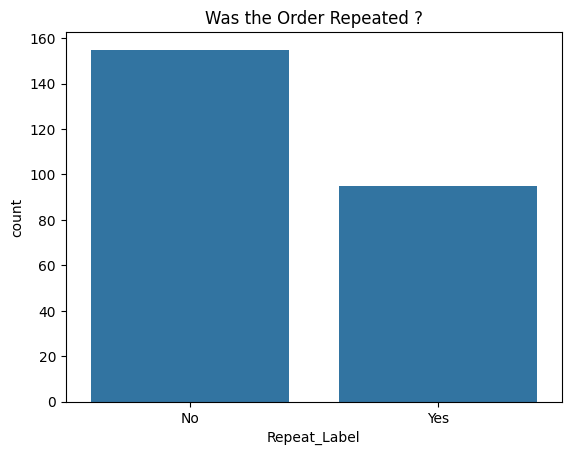

In [22]:
sns.barplot(x=df["Repeat_Label"].value_counts().index,y=df["Repeat_Label"].value_counts())
plt.title("Was the Order Repeated ?")
plt.show()

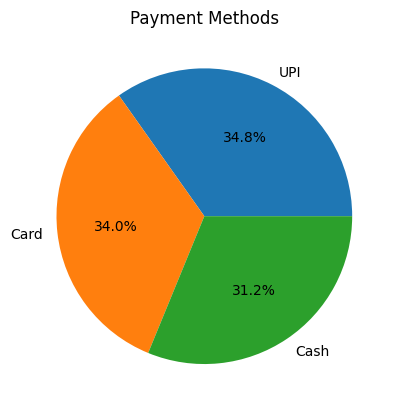

In [23]:
plt.pie(df["Payment_Method"].value_counts(),labels=df["Payment_Method"].value_counts().index,autopct="%1.1f%%")
plt.title("Payment Methods")
plt.show()

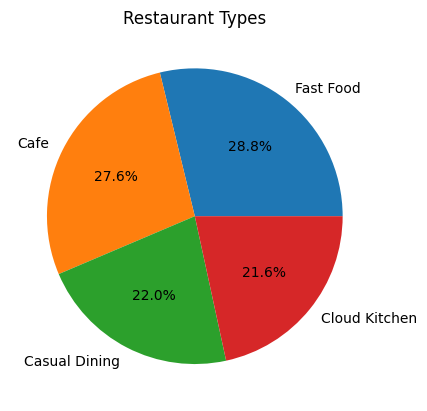

In [24]:
plt.pie(df["Restaurant_Type"].value_counts(),labels=df["Restaurant_Type"].value_counts().index,autopct="%1.1f%%")
plt.title("Restaurant Types")
plt.show()

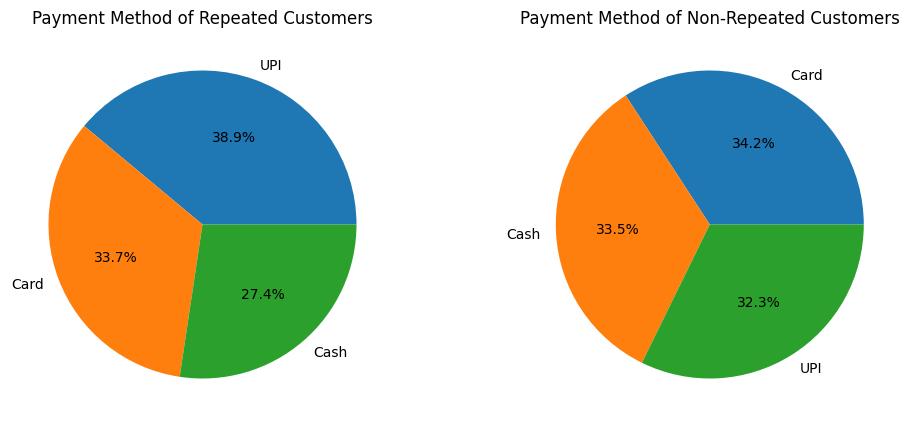

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(repeated["Payment_Method"].value_counts(),labels=repeated["Payment_Method"].value_counts().index,autopct="%1.1f%%")
axes[0].set_title("Payment Method of Repeated Customers")
axes[1].pie(not_repeated["Payment_Method"].value_counts(),labels=not_repeated["Payment_Method"].value_counts().index,autopct="%1.1f%%")
axes[1].set_title("Payment Method of Non-Repeated Customers")
plt.show()

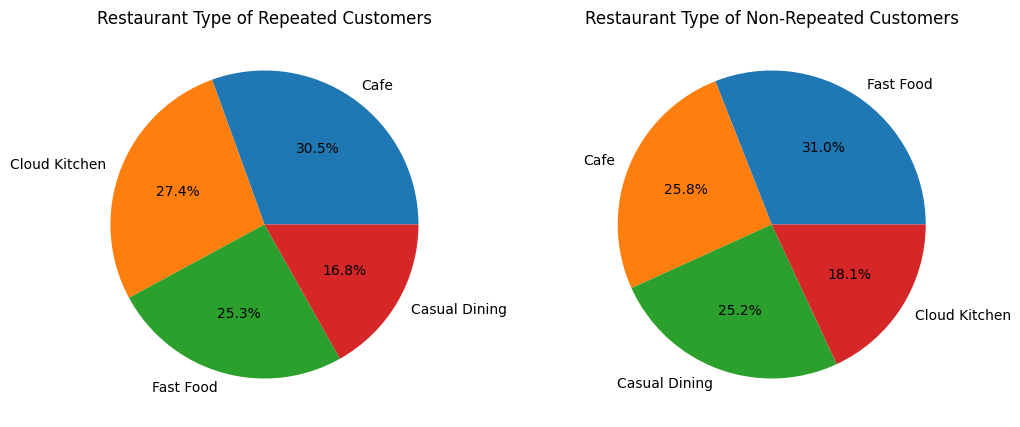

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(repeated["Restaurant_Type"].value_counts(),labels=repeated["Restaurant_Type"].value_counts().index,autopct="%1.1f%%")
axes[0].set_title("Restaurant Type of Repeated Customers")
axes[1].pie(not_repeated["Restaurant_Type"].value_counts(),labels=not_repeated["Restaurant_Type"].value_counts().index,autopct="%1.1f%%")
axes[1].set_title("Restaurant Type of Non-Repeated Customers")
plt.show()

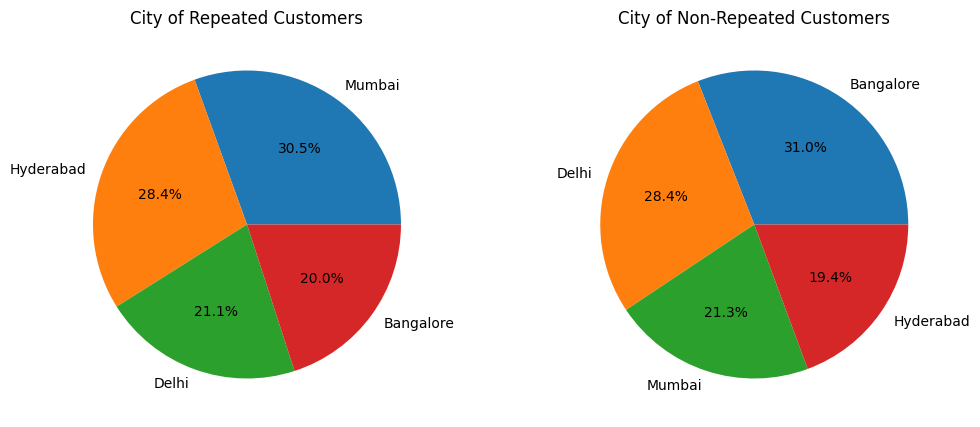

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(repeated["City"].value_counts(),labels=repeated["City"].value_counts().index,autopct="%1.1f%%")
axes[0].set_title("City of Repeated Customers")
axes[1].pie(not_repeated["City"].value_counts(),labels=not_repeated["City"].value_counts().index,autopct="%1.1f%%")
axes[1].set_title("City of Non-Repeated Customers")
plt.show()

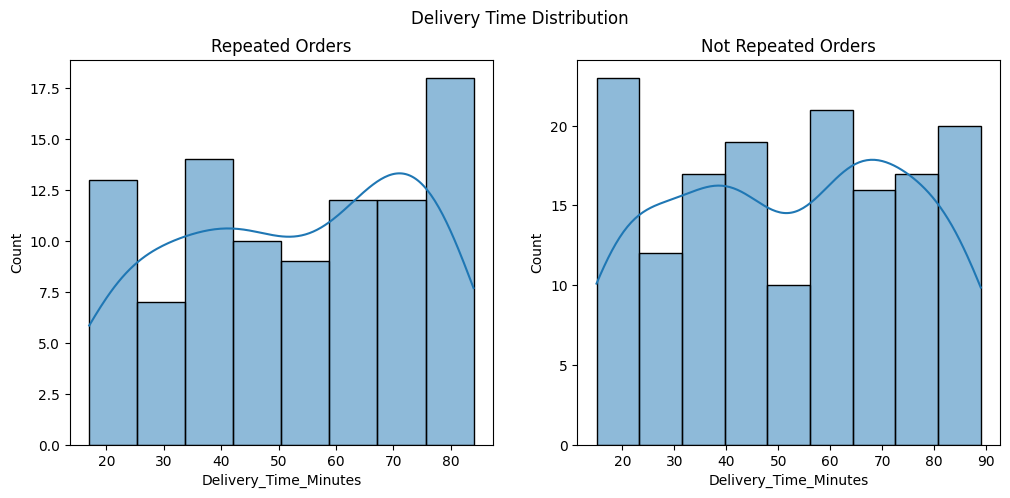

In [27]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=repeated, x="Delivery_Time_Minutes", kde=True, ax=axes[0])
sns.histplot(data=not_repeated, x="Delivery_Time_Minutes", kde=True, ax=axes[1])
axes[0].set_title("Repeated Orders")
axes[1].set_title("Not Repeated Orders")
fig.suptitle("Delivery Time Distribution")
plt.show()

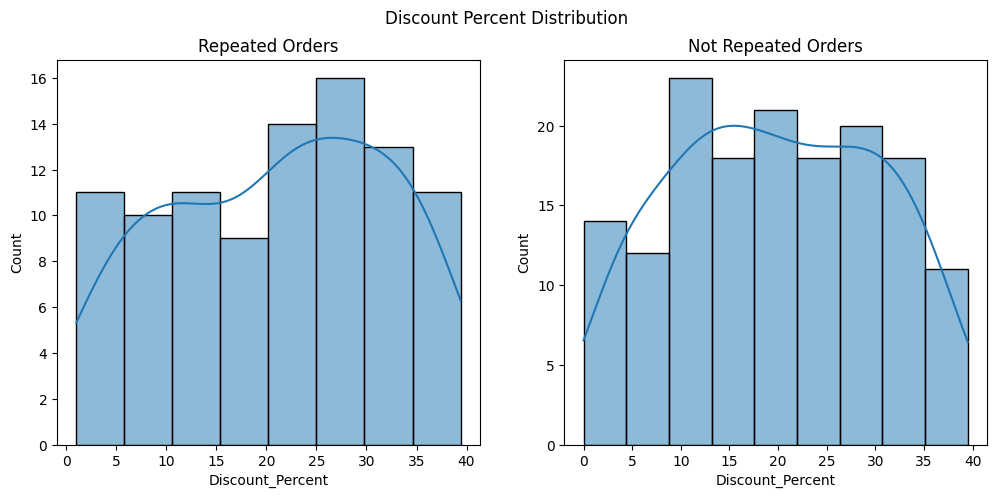

In [28]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=repeated, x="Discount_Percent", kde=True, ax=axes[0])
sns.histplot(data=not_repeated, x="Discount_Percent", kde=True, ax=axes[1])
axes[0].set_title("Repeated Orders")
axes[1].set_title("Not Repeated Orders")
fig.suptitle("Discount Percent Distribution")
plt.show()

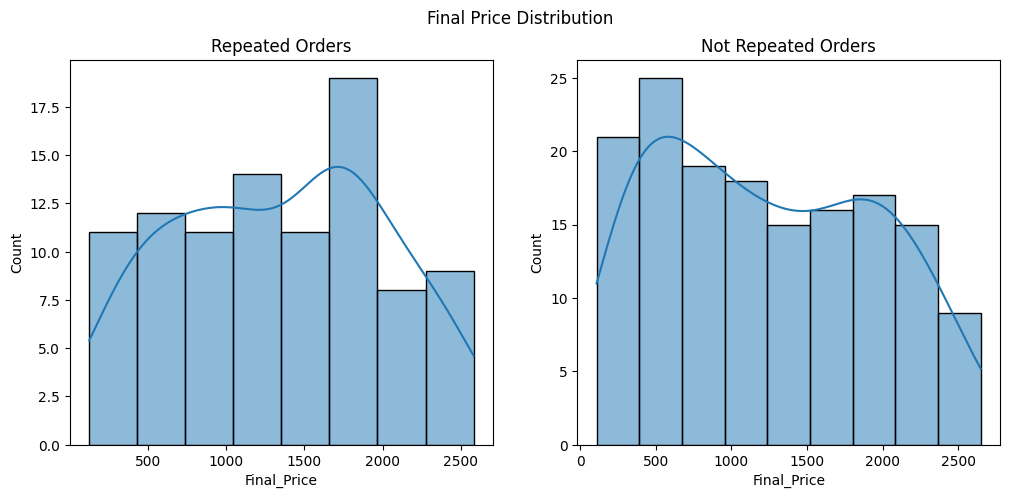

In [29]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=repeated, x="Final_Price", kde=True, ax=axes[0])
sns.histplot(data=not_repeated, x="Final_Price", kde=True, ax=axes[1])
axes[0].set_title("Repeated Orders")
axes[1].set_title("Not Repeated Orders")
fig.suptitle("Final Price Distribution")
plt.show()

# Conclusion
- From the repeated customers, most of them payed using UPI while for non-repeated customers, most of them used card. This shows since upi is an easier method to pay, users don't feel frustated while paying while with card, it requires way more effort for paying.
- Bangalore has the least percentage of repeating customers and most non-repeating customers which shows the company needs to focus more on Bangalore since the people of Bangalore are not impressed by their food delivery.
- Most of the repeated customers had got their delivery 75-85 mins while non repeating got in 0-25 mins. This is a slightly suprising found since its mostly the other way around. One reason might me that their might me any restaurant that is extremely good but far away and ordering it online means they ccan enjoy the food in their home itself due to which the customer is ordering again despite the long delivery time.
- People who got 25-30% discount reordered but people who got 10-15% were the people who didn't reorder. This shows that people getting less discount has to pay more money which makes them not want to order again.
- Maxmimum people who reordered ordered food worth in the range 1600-2400 while the people who didn't bought food worth 400-700. This shows although people want discount, but they are still ready to pay more if the quality of food is good.